# Section 3 — Assignment 1
# Computer Vision Fundamentals

**IOAI 2026 Preparation**

**Topics:** Convolutional Layers, Image Classification, Pre-trained Vision Encoders (ResNet), Image Augmentation, Self-Supervised Learning for Vision

**Instructions:**
- Write all your code in the empty cells provided below each question.
- You may add extra cells if needed.
- Use **PyTorch** and **torchvision** throughout.
- Answer written questions as comments or in a new markdown cell.

---
## Problem 1 — Convolutional Layers: Theory & Exploration

1. Load any grayscale image (or use `PIL` to create a simple one). Apply a **2D convolution** manually using NumPy (without PyTorch's `nn.Conv2d`) with the following 3×3 kernels and display the resulting feature maps:
   - Horizontal edge detector: `[[-1,-1,-1],[0,0,0],[1,1,1]]`
   - Vertical edge detector: `[[-1,0,1],[-1,0,1],[-1,0,1]]`
   - Gaussian blur: 3×3 kernel with all values = 1/9

2. Using PyTorch's `nn.Conv2d`, create a layer with 1 input channel, 8 output channels, kernel_size=3, and stride=1 with padding=1. Compute the output shape for an input of size (1, 1, 28, 28). Verify by passing a random tensor through it.

3. Demonstrate the effect of **stride** and **padding** on output size. For an input of (1, 1, 32, 32), compute and verify the output shapes for:
   - kernel=3, stride=1, padding=0
   - kernel=3, stride=2, padding=1
   - kernel=5, stride=1, padding=2

4. What is the **receptive field** of a convolutional neuron? Compute the receptive field size after stacking 3 consecutive Conv2d layers each with kernel_size=3 and stride=1.

5. What is the difference between **valid** and **same** padding? Why do most modern CNNs use same padding in intermediate layers?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

In [ ]:
def convolve2d(img, kernel):
    img_h, img_w = img.shape
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(img, ((ph, ph), (pw, pw)), mode="constant")
    out = np.zeros_like(img)
    for r in range(img_h):
        for c in range(img_w):
            region = padded[r : r + kh, c : c + kw]
            out[r, c] = np.sum(region * kernel)
    return out

In [ ]:
img = np.zeros((64, 64))
img[16:48, 16:48] = 255

In [ ]:
k_hor = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
k_ver = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
k_blur = np.ones((3, 3)) / 9.0

In [ ]:
f_hor = convolve2d(img, k_hor)
f_ver = convolve2d(img, k_ver)
f_blur = convolve2d(img, k_blur)

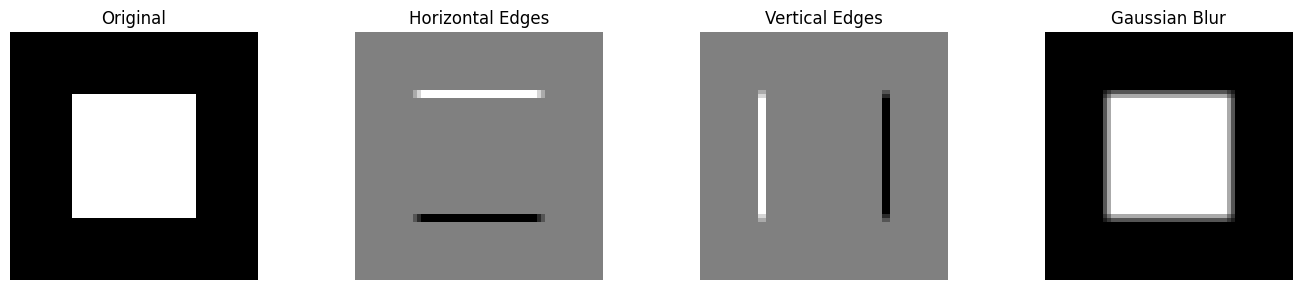

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
imgs = [img, f_hor, f_ver, f_blur]
titles = ["Original", "Horizontal Edges", "Vertical Edges", "Gaussian Blur"]
for ax, i, t in zip(axes, imgs, titles):
    ax.imshow(i, cmap="gray")
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
conv_a = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)
out_a = conv_a(torch.randn(1, 1, 28, 28))
print(f"Case A Shape: {list(out_a.shape)}")

Case A Shape: [1, 8, 28, 28]


In [ ]:
t_32 = torch.randn(1, 1, 32, 32)

In [ ]:
b1 = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0)(t_32)
print(f"B1 (K=3, S=1, P=0) Shape: {list(b1.shape)}")

B1 (K=3, S=1, P=0) Shape: [1, 1, 30, 30]


In [ ]:
b2 = nn.Conv2d(1, 1, kernel_size=3, stride=2, padding=1)(t_32)
print(f"B2 (K=3, S=2, P=1) Shape: {list(b2.shape)}")

B2 (K=3, S=2, P=1) Shape: [1, 1, 16, 16]


In [ ]:
b3 = nn.Conv2d(1, 1, kernel_size=5, stride=1, padding=2)(t_32)
print(f"B3 (K=5, S=1, P=2) Shape: {list(b3.shape)}")

B3 (K=5, S=1, P=2) Shape: [1, 1, 32, 32]


The area of the image that a convolutional neuron looks at is called the receptive field. This is the part of the image that the convolutional neuron can see and get information, from. The convolutional neuron uses this field to find important things in the image.

Stacking these three layers gives a single deep neuron a final receptive field of $7 \times 7$.

Valid Padding: There is no space added to the picture. The kernel only looks at the pixels where it can fit inside the picture. This means the picture gets a little smaller at every step.

Same Padding: The computer adds zeros around the edges of the picture so the new picture is the size as the old one. This happens when the stride is one.

Why Modern CNNs Use "Same": This method stops the picture from getting too small quickly. It makes sure the picture does not shrink down to a size, in deep layers. It also helps keep the details at the edges of the picture.

---
## Problem 2 — CNN for Image Classification

Build and train a CNN on **CIFAR-10** (10 classes, 32×32 color images).

1. Design a CNN with the following architecture:
   - Conv(3→32, k=3, p=1) → BatchNorm → ReLU → MaxPool(2×2)
   - Conv(32→64, k=3, p=1) → BatchNorm → ReLU → MaxPool(2×2)
   - Conv(64→128, k=3, p=1) → BatchNorm → ReLU → MaxPool(2×2)
   - Flatten → Dense(512) → ReLU → Dropout(0.5) → Dense(10)

2. Train for 20 epochs using Adam (lr=0.001), CrossEntropyLoss, and a StepLR scheduler. Use DataLoaders with batch_size=128.

3. Plot the training loss and test accuracy per epoch.

4. Display the **confusion matrix** on the test set. Which classes does the model confuse most often? Why might that be?

5. Visualize 5 convolutional filters from the first Conv layer as images. What patterns do they detect?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform_train = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),])
transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),])
train_set = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train)
test_set = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:04<00:00, 36.8MB/s]


In [ ]:
classes = [
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

In [ ]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10),)
    def forward(self, x):
        return self.classifier(self.features(x))

In [ ]:
model = CIFAR_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = StepLR(optimizer, step_size=7, gamma=0.5)

In [ ]:
epochs = 20
train_losses, test_accs = [], []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    scheduler.step()
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    epoch_acc = (correct / total) * 100
    test_accs.append(epoch_acc)
    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Epoch 01/20 | Loss: 1.5457 | Accuracy: 57.09%
Epoch 02/20 | Loss: 1.2203 | Accuracy: 61.28%
Epoch 03/20 | Loss: 1.0821 | Accuracy: 68.34%
Epoch 04/20 | Loss: 1.0036 | Accuracy: 67.49%
Epoch 05/20 | Loss: 0.9359 | Accuracy: 72.48%
Epoch 06/20 | Loss: 0.8837 | Accuracy: 72.42%
Epoch 07/20 | Loss: 0.8507 | Accuracy: 74.39%
Epoch 08/20 | Loss: 0.7642 | Accuracy: 76.93%
Epoch 09/20 | Loss: 0.7355 | Accuracy: 78.06%
Epoch 10/20 | Loss: 0.7264 | Accuracy: 77.38%
Epoch 11/20 | Loss: 0.6989 | Accuracy: 78.46%
Epoch 12/20 | Loss: 0.6822 | Accuracy: 77.62%
Epoch 13/20 | Loss: 0.6799 | Accuracy: 78.23%
Epoch 14/20 | Loss: 0.6627 | Accuracy: 79.13%
Epoch 15/20 | Loss: 0.6254 | Accuracy: 80.48%
Epoch 16/20 | Loss: 0.6108 | Accuracy: 81.00%
Epoch 17/20 | Loss: 0.6053 | Accuracy: 81.21%
Epoch 18/20 | Loss: 0.5946 | Accuracy: 81.34%
Epoch 19/20 | Loss: 0.5900 | Accuracy: 81.25%
Epoch 20/20 | Loss: 0.5829 | Accuracy: 81.53%


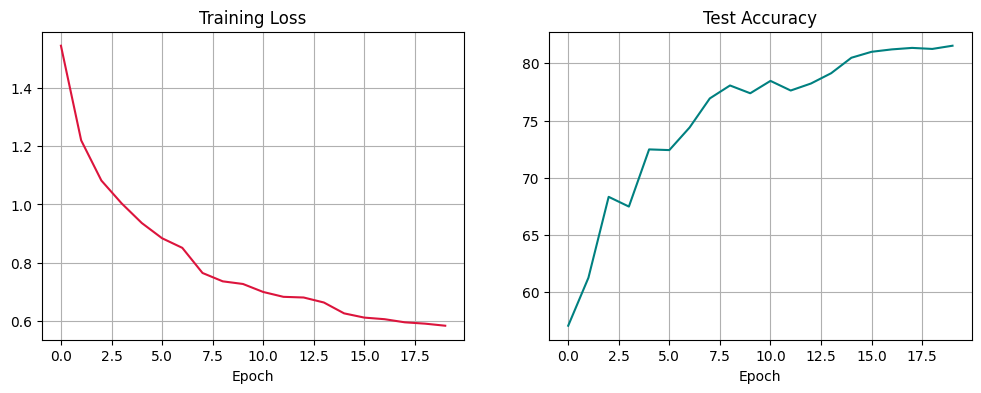

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color="crimson")
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.grid(True)

ax2.plot(test_accs, color="teal")
ax2.set_title("Test Accuracy")
ax2.set_xlabel("Epoch")
ax2.grid(True)
plt.show()

In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

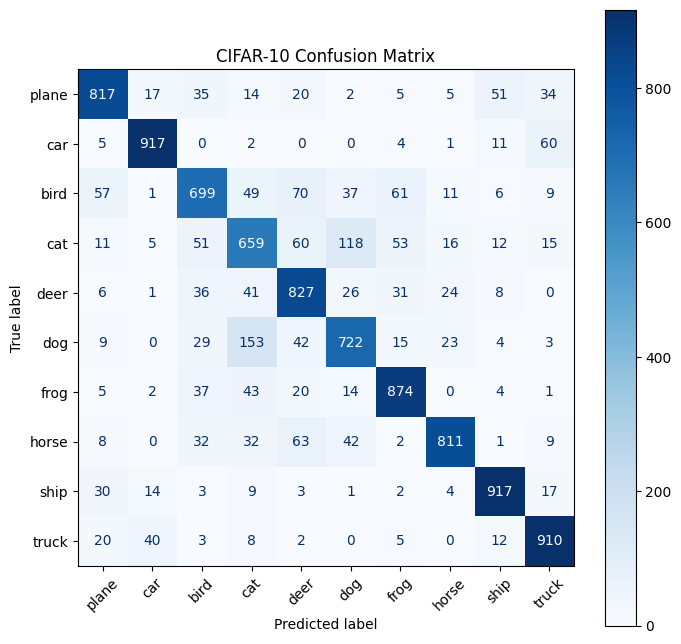

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.xticks(rotation=45)
plt.title("CIFAR-10 Confusion Matrix")
plt.show()

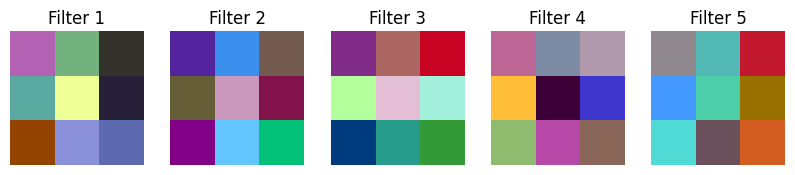

In [ ]:
filters = model.features[0].weight.data.cpu().numpy()
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    f = filters[i]
    f = (f - f.min()) / (f.max() - f.min())
    axes[i].imshow(np.transpose(f, (1, 2, 0)))
    axes[i].set_title(f"Filter {i+1}")
    axes[i].axis("off")
plt.show()

The network has a lot of trouble telling cats and dogs apart and also planes and ships.

Cat vs. Dog: Cats and dogs look very similar because they have the kind of fur and things like ears and eyes. They also have four legs and people usually have them in their homes.

Plane vs. Ship: The network gets confused about planes and ships because of what's in the background. Planes are usually in the sky and ships are usually, in the water.

The first layer of filters looks at the raw pixel values of the 3 RGB channels. These filters show us some patterns:

* Color contrasts: You can see patches of colors like reds and oranges that clash with cool colors like blues and greens.

The color contrasts stand out.

* Edge components: These are lines that can be horizontal, vertical or diagonal. They light up when they cross the edges of objects.

* Blob and Texture kernels: These are gradients that get darker or lighter towards the center. They help us see changes, in lighting and texture. Blob kernels are useful.

---
## Problem 3 — Image Augmentation

1. Using `torchvision.transforms`, apply the following augmentations to a CIFAR-10 image and display the original alongside 8 augmented versions:
   - Random horizontal flip
   - Random crop (size=28, padding=4)
   - Color jitter (brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)
   - Random rotation (±15 degrees)
   - Random grayscale (p=0.2)
   - Gaussian blur (kernel=3)

2. Retrain your CNN from Problem 2, this time **with** the above augmentations applied to the training set only. Compare:
   - Train accuracy (with vs without augmentation)
   - Test accuracy (with vs without augmentation)
   
3. Implement **CutMix** or **MixUp** augmentation manually (choose one). Apply it during training and show the resulting augmented images. Report whether it improves test accuracy.

4. Why should augmentations only be applied to the **training** set and not the validation/test set? Are there any exceptions?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_transform = transforms.Compose([transforms.ToTensor()])
vis_set = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=base_transform
)
img_tensor, _ = vis_set[0]
pil_img = transforms.ToPILImage()(img_tensor)

In [ ]:
aug_dict = {
    "Horizontal Flip": transforms.RandomHorizontalFlip(p=1.0),
    "Random Crop": transforms.RandomCrop(28, padding=4),
    "Color Jitter": transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    "Random Rotation": transforms.RandomRotation(15),
    "Random Grayscale": transforms.RandomGrayscale(p=1.0),
    "Gaussian Blur": transforms.GaussianBlur(3),
    "Combined 1": transforms.Compose(
        [transforms.RandomHorizontalFlip(), transforms.ColorJitter(0.4, 0.4)]),
    "Combined 2": transforms.Compose(
        [transforms.RandomRotation(15), transforms.GaussianBlur(3)]),}

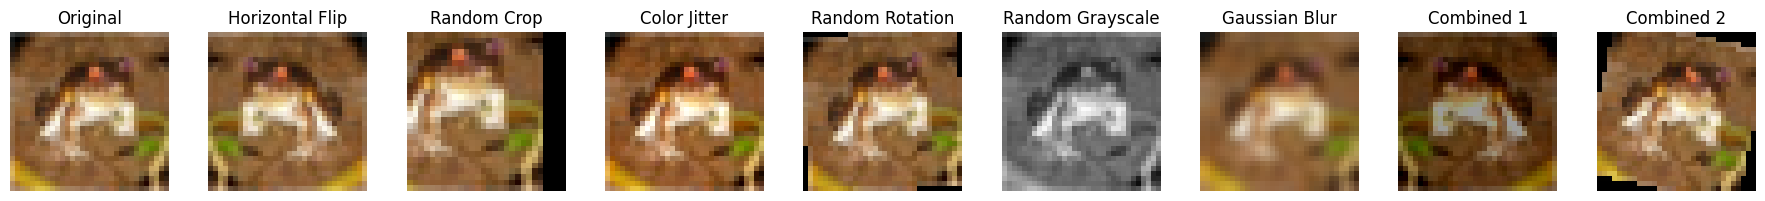

In [ ]:
fig, axes = plt.subplots(1, 9, figsize=(18, 2))
axes[0].imshow(img_tensor.permute(1, 2, 0))
axes[0].set_title("Original")
axes[0].axis("off")

for i, (title, aug) in enumerate(aug_dict.items(), 1):
    aug_img = aug(pil_img)
    axes[i].imshow(np.array(aug_img))
    axes[i].set_title(title)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

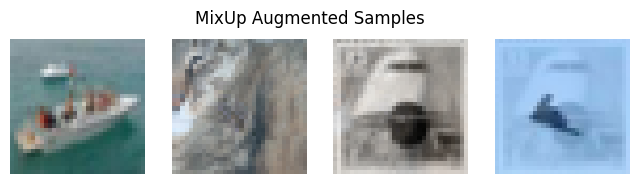

In [ ]:
vis_loader = DataLoader(vis_set, batch_size=4, shuffle=True)
images, labels = next(iter(vis_loader))
images, labels = images.to(device), labels.to(device)
mixed_ims, _, _, _ = mixup_data(images, labels, alpha=0.4)
fig, axes = plt.subplots(1, 4, figsize=(8, 2))
for i in range(4):
    axes[i].imshow(mixed_ims[i].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[i].axis("off")
plt.suptitle("MixUp Augmented Samples")
plt.show()

In [ ]:
train_transform_aug = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
        transforms.RandomRotation(15),
        transforms.RandomGrayscale(p=0.2),
        transforms.GaussianBlur(3),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),])

test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),])
train_set_aug = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_transform_aug)
test_set = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform)
train_loader_aug = DataLoader(train_set_aug, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

In [ ]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10),)
    def forward(self, x):
        return self.classifier(self.features(x))

In [ ]:
model = CIFAR_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for imgs, lbls in train_loader_aug:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, preds = torch.max(model(imgs), 1)
            total += lbls.size(0)
            correct += (preds == lbls).sum().item()
    print(f"Epoch {epoch+1} | Loss: {running_loss / len(train_set_aug):.4f} | Test Acc: {(correct / total) * 100:.2f}%")

Epoch 1 | Loss: 1.8512 | Test Acc: 45.77%
Epoch 2 | Loss: 1.6105 | Test Acc: 55.06%
Epoch 3 | Loss: 1.4947 | Test Acc: 59.21%
Epoch 4 | Loss: 1.4096 | Test Acc: 60.90%
Epoch 5 | Loss: 1.3519 | Test Acc: 64.07%


The evaluation sets need to be very similar, to the data we see in the world. If we add noise or rotate the validation or test samples it changes the data in a way that's not real. The evaluation sets must accurately mimic real-world deployment data distributions of the evaluation sets.

Exceptions :-

1.) Test-Time Augmentation (TTA)

2.)Domain Alignment / Normalization Checking

---
## Problem 4 — Transfer Learning with ResNet

1. Load `resnet18` with pretrained ImageNet weights from `torchvision.models`. Print its architecture and count the total number of parameters.

2. Adapt it to classify **10 CIFAR-10 classes**:
   - Replace the final fully connected layer.
   - Freeze all layers except the last residual block and the final FC layer.
   - Train for 10 epochs.

3. Compare three strategies:
   - **Feature extraction**: freeze everything, only train the new FC layer.
   - **Partial finetuning**: unfreeze the last residual block + FC.
   - **Full finetuning**: unfreeze all layers with a smaller lr=0.0001.
   
   Plot test accuracy for all three strategies over epochs.

4. Visualize the **feature maps** from the first and last convolutional block for a sample image. What do you observe? How do early vs late features differ?

5. Why does transfer learning from ImageNet work well for CIFAR-10, even though ImageNet images are 224×224 and CIFAR-10 images are 32×32?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform_train = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),])
transform_test = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),])
train_full = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train)
test_full = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test)
train_sub = torch.utils.data.Subset(train_full, list(range(1000)))
test_sub = torch.utils.data.Subset(test_full, list(range(500)))
train_loader = DataLoader(train_sub, batch_size=64, shuffle=True)
test_loader = DataLoader(test_sub, batch_size=64, shuffle=False)

In [ ]:
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
total_params = sum(p.numel() for p in base_model.parameters())
print(f"Total Parameters: {total_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


Total Parameters: 11,689,512


In [ ]:
def run_strategy(setup_fn, lr, name):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 10)
    setup_fn(model)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    acc_history = []
    for epoch in range(10):
        model.train()
        for ims, lbls in train_loader:
            ims, lbls = ims.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(ims), lbls)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for ims, lbls in test_loader:
                ims, lbls = ims.to(device), lbls.to(device)
                outputs = model(ims)
                _, preds = torch.max(outputs, 1)
                total += lbls.size(0)
                correct += (preds == lbls).sum().item()
        acc = (correct / total) * 100
        acc_history.append(acc)
    return acc_history

In [ ]:
def setup_feature_extraction(model):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True
def setup_partial_finetuning(model):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.layer4.parameters():
        p.requires_grad = True
    for p in model.fc.parameters():
        p.requires_grad = True
def setup_full_finetuning(model):
    for p in model.parameters():
        p.requires_grad = True

In [ ]:
acc_feat = run_strategy(setup_feature_extraction, 0.001, "Feature Extraction")
acc_part = run_strategy(setup_partial_finetuning, 0.001, "Partial Finetuning")
acc_full = run_strategy(setup_full_finetuning, 0.0001, "Full Finetuning")

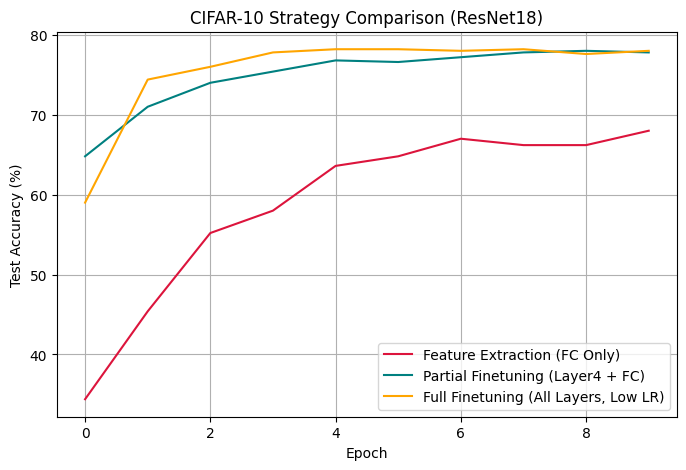

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(acc_feat, label="Feature Extraction (FC Only)", color="crimson")
plt.plot(acc_part, label="Partial Finetuning (Layer4 + FC)", color="teal")
plt.plot(acc_full, label="Full Finetuning (All Layers, Low LR)", color="orange")
plt.title("CIFAR-10 Strategy Comparison (ResNet18)")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
vis_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
activations = {}
def get_hook(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu()
    return hook

In [ ]:
vis_model.conv1.register_forward_hook(get_hook("early"))
vis_model.layer4[1].conv2.register_forward_hook(get_hook("late"))

In [ ]:
sample_img, _ = train_full[0]
vis_model.eval()
with torch.no_grad():
    _ = vis_model(sample_img.unsqueeze(0).to(device))

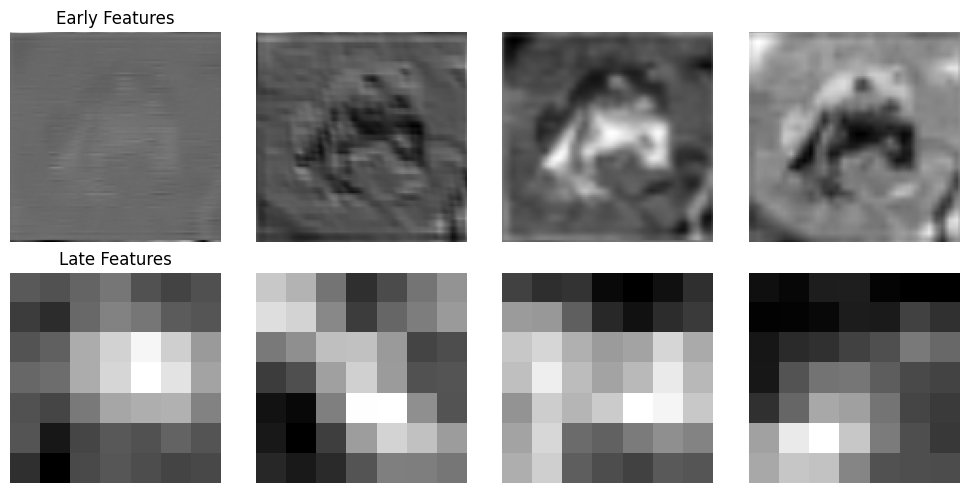

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i in range(4):
    axes[0, i].imshow(activations["early"][0, i], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Early Features")
    axes[1, i].imshow(activations["late"][0, i], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Late Features")
plt.tight_layout()
plt.show()

Early Layers, also known as conv1 have a spatial resolution.

They help us see sharp details.

These details include edges, lines, textures and where colors change.

Late Layers, also known as layer4 have a spatial resolution and are more abstract.

They do not show structures.

Instead they appear as areas.

These areas indicate ideas, such, as a wheel or an eye.

Both datasets have world objects that look the same. The simple things that the computer learns from ImageNet like lines and patterns on things are the same everywhere. If we make the pictures in CIFAR-10 than 32 x 32 it does not add more details to the pictures.. It does make the simple patterns in the pictures bigger so they fit the pretrained filters better. The pretrained filters are, like tools that the computer uses to look at pictures.

---
## Problem 5 — Pooling Operations & Global Average Pooling

1. For a 6×6 feature map, compute and display the output of:
   - Max Pooling (2×2, stride=2)
   - Average Pooling (2×2, stride=2)
   - Global Average Pooling (reduces entire map to a single value per channel)

2. Explain the difference between Max and Average Pooling. In what scenarios would each be preferred?

3. Many modern architectures replace the final Flatten + Dense block with **Global Average Pooling** (GAP) followed by a single dense layer. What are the advantages of GAP over flattening:
   - In terms of parameter count?
   - In terms of spatial invariance?
   - In terms of handling variable input sizes?

4. Modify the CNN from Problem 2 to use Global Average Pooling before the final dense layer. Does accuracy change? Does the number of parameters decrease significantly?

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
feat_map = np.array(
    [
        [12, 20, 30, 0, 8, 12],
        [8, 12, 2, 5, 4, 0],
        [34, 70, 37, 4, 9, 1],
        [112, 10, 25, 12, 6, 7],
        [1, 4, 8, 9, 50, 40],
        [2, 3, 0, 1, 10, 20],])

In [ ]:
out_h, out_w = 3, 3
max_pool_out = np.zeros((out_h, out_w))
avg_pool_out = np.zeros((out_h, out_w))
for r in range(out_h):
    for c in range(out_w):
        region = feat_map[r * 2 : r * 2 + 2, c * 2 : c * 2 + 2]
        max_pool_out[r, c] = np.max(region)
        avg_pool_out[r, c] = np.mean(region)
gap_out = np.mean(feat_map)

In [ ]:
print(f"Max Pooling (2x2, S=2):\n{max_pool_out}\n")
print(f"Average Pooling (2x2, S=2):\n{avg_pool_out}\n")
print(f"Global Average Pooling (GAP) Output: {gap_out:.2f}\n")

Max Pooling (2x2, S=2):
[[ 20.  30.  12.]
 [112.  37.   9.]
 [  4.   9.  50.]]

Average Pooling (2x2, S=2):
[[13.    9.25  6.  ]
 [56.5  19.5   5.75]
 [ 2.5   4.5  30.  ]]

Global Average Pooling (GAP) Output: 16.33



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class GAP_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, 10)
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [ ]:
original_fc_params = (128 * 4 * 4 * 512) + 512 + (512 * 10) + 10
gap_fc_params = (128 * 10) + 10
print(f"GAP Classifier Params: {gap_fc_params}")
print(f"Saved Classifier Params: {original_fc_params - gap_fc_params:,}\n")

GAP Classifier Params: 1290
Saved Classifier Params: 1,052,928



In [ ]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),])
train_set = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(
    torch.utils.data.Subset(train_set, list(range(1000))),
    batch_size=128,
    shuffle=True,)
test_loader = DataLoader(
    torch.utils.data.Subset(test_set, list(range(500))),
    batch_size=128,
    shuffle=False,)
model = GAP_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
model.train()
for ims, lbls in train_loader:
    ims, lbls = ims.to(device), lbls.to(device)
    optimizer.zero_grad()
    loss = criterion(model(ims), lbls)
    loss.backward()
    optimizer.step()

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for ims, lbls in test_loader:
        ims, lbls = ims.to(device), lbls.to(device)
        _, preds = torch.max(model(ims), 1)
        total += lbls.size(0)
        correct += (preds == lbls).sum().item()
print(f"GAP Model Test Accuracy (1 Epoch Baseline): {(correct/total)*100:.2f}%")

GAP Model Test Accuracy (1 Epoch Baseline): 20.80%


Parameter Count: When we do flattening it makes vectors. These vectors need millions of connections to the layer. On the hand GAP takes each feature map and turns it into just one value. This greatly reduces the number of parameters in the classification head by, than 99%. As a result it also reduces overfitting a lot.

Spatial Invariance:

* Flattening needs features at spots.

* Global Average Pooling, GAP adds up the maps over their area.

This way GAP checks if a feature exists anywhere, in an image.

It does not matter where the feature moved to; GAP still finds it.

So GAP provides translation invariance.

Variable input sizes can cause problems.

When using layers connected to a flattened vector they can break if the image dimensions change.

The Global Average Pooling (GAP) layer solves this issue.

It adjusts to any spatial map size, which is height times width ($H \times W$) by finding the average value.

This allows the network to handle input sizes smoothly.

---
## Reflection Questions

Answer in a markdown cell or as comments:

1. Why do CNNs use **local connectivity** and **weight sharing**? How does this reduce the parameter count compared to a fully connected layer on an image?
2. Explain **translation invariance** vs **translation equivariance**. Which property do convolutional layers have, and which do pooling layers introduce?
3. ResNet introduced **skip connections** (residual connections). Why do plain deep networks suffer from degradation (not just vanishing gradients), and how do skip connections address this?
4. If you have only 500 labeled images for a 5-class classification task, would you train a CNN from scratch or use transfer learning? Justify your choice.

1. Local Connectivity and Weight Sharing

   Local Connectivity: A convolutional neuron does not connect to every pixel it only connects to a small group of pixels that are close by this is called the kernel size.

   Weight Sharing: The same kernel moves across the picture using the same weights every time it moves to a new spot.

   Parameter Reduction: If we use a layer to connect a picture that is 256 by 256 by 3 to 64 neurons we need 12.5 million weights.. If we use a convolutional layer that is 3 by 3 with 64 filters we only need 1,728 weights because the number of weights we need is based on the size of the kernel not the size of the picture. Local Connectivity and Weight Sharing help, with this.

2. Invariance versus Equivariance

Translation Equivariance is when the input moves the output also moves by the same amount. This means that if something is in a place the computer sees it in a different place too. Convolutional layers do this. They show where things are in a picture.

Translation Invariance is when the input moves. The final output is still the same. This means that if something is in a place the computer still sees it as the same thing. Pooling layers help with this. They look at an area and say what is the most important thing there so the computer does not worry about small changes, in position.

3. Skip Connections and Degradation

The Degradation Problem: When we make plain networks deeper their accuracy gets better at first but then it stops improving and even drops quickly. This issue isn't about gradients getting smaller; it's that deeper layers have trouble learning simple things like copying the input to the output.

The Fix: Skip connections help by sending the input right past the layers with weights. This way if the weighted layers do nothing the network just acts like a copy layer. This keeps it easy for the model to learn and add depth without losing performance.

4. 500 Images, 5 Classes: Scratch vs. Transfer Learning

Choice: Transfer Learning.

Justification: We do not have images to train a CNN from scratch. We have 500 Images and 5 Classes, which is not a lot. We only have 100 images per class. This is a problem because the model will learn the training set quickly and then it will not work well with new images.

Transfer Learning is a choice, for 500 Images and 5 Classes. A model that was trained on ImageNet already knows what edges and shapes and textures look like. So we can use this model. Just teach it about our 5 target classes. We do this by retraining the linear layer of the Transfer Learning model to recognize our 5 target classes. This way the model will work better with 500 Images and 5 Classes.